# Analysis 2 — Coal/iron-ore quasi-experiments (state-level + project-level)

**Causal question**: Did Japanese equity stakes and long-term SPAs in Australian coal/iron-ore projects lock in disproportionate flows to Japan?

## Data-availability reality

After investigating ABARES (starts 2012), QLD Coal Industry Review open data (starts FY2010), AIMR (narrative PDFs, no clean annual mine tables), and the Mudd (2023) Nature Scientific Data dataset (state-level annual production 1799–2021), the realistic picture:

- **Mine-by-mine annual production pre-2010 is NOT publicly scrapeable.** It exists in BHP/Rio Tinto/BMA annual report PDFs and in print archives of *Joint Coal Board Annual Reports* (NSW) and *Queensland Coal Industry Review* (QLD pre-2010), but these are not in tabular open form.
- **State-level annual production back to 1799** IS available via Mudd (2023) — `data/processed/mudd_coal_iron_state_panel.csv`. Enables a coarser DiD design.
- The fully project-level event study around BMA 2001 remains a hand-coding exercise.

## Three specifications

1. **Specification A (primary, runs out-of-the-box)** — State-level DiD: QLD (treated, BMA Japanese equity 15→50% in 2001) vs NSW (control, predominantly thermal coal) around 2001.
2. **Specification B (cross-section, seed data only)** — Where `japan_share_of_output_pct` is observed, regress on Japanese equity %.
3. **Specification C (aspirational project-level)** — Requires hand-coded BMA + control-mine annual production.

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

REPO = Path().resolve().parents[0] if Path().resolve().name == 'notebooks' else Path().resolve()
PROC = REPO / 'data' / 'processed'
MAN = REPO / 'data' / 'manual'

mudd = pd.read_csv(PROC / 'mudd_coal_iron_state_panel.csv')
fossil = pd.read_csv(PROC / 'fossil_era_panel.csv')
project_panel = pd.read_csv(PROC / 'project_year_panel.csv')
print('Mudd state-level panel:', mudd.shape)
print('Fossil-era macro panel:', fossil.shape)
print('Project-year panel:', project_panel.shape)

Mudd state-level panel: (1764, 4)
Fossil-era macro panel: (63, 29)
Project-year panel: (242, 20)


## Specification A — State-level DiD: QLD vs NSW around BMA 2001

QLD is where the BMA Japanese-equity transition occurred (Goonyella, Peak Downs, Saraji — all in QLD's Bowen Basin). NSW has substantial coal output but much smaller Japanese equity exposure. If the 2001 Mitsubishi step-up caused a real expansion of Japan-oriented capacity, QLD coal output should rise relative to NSW around 2001–2005.

Event-time dummies are named `dlead{n}` (for years before 2001) and `dlag{n}` (year 2001 onward). Reference period: $t=2000$ (`dlead1`).

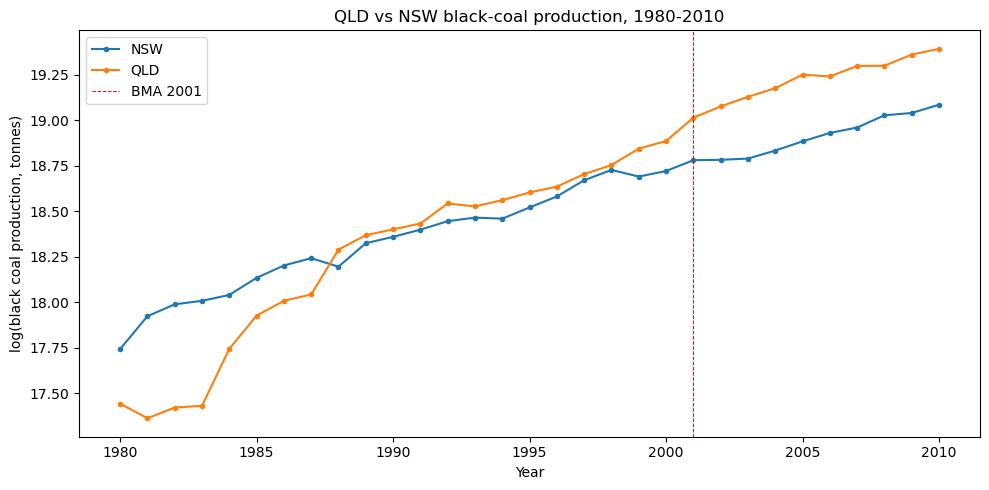

In [7]:
sa = mudd[(mudd.commodity == 'black_coal')
          & (mudd.state.isin(['QLD', 'NSW']))
          & (mudd.year.between(1980, 2010))].copy()
sa['log_prod'] = np.log(sa['production_tonnes'])
sa['treated_qld'] = (sa.state == 'QLD').astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
for state, sub in sa.groupby('state'):
    ax.plot(sub.year, sub.log_prod, 'o-', label=state, ms=3)
ax.axvline(2001, color='red', lw=0.7, ls='--', label='BMA 2001')
ax.set_xlabel('Year'); ax.set_ylabel('log(black coal production, tonnes)')
ax.set_title('QLD vs NSW black-coal production, 1980-2010')
ax.legend(); plt.tight_layout(); plt.show()

In [8]:
EVENT_LEADS = range(1, 4)   # 3 leads — 1998, 1999, 2000 (dlead1=2000 is omitted ref)
EVENT_LAGS = range(0, 4)    # 4 lags — 2001, 2002, 2003, 2004

for n in EVENT_LEADS:
    if n == 1:  # omitted reference (year 2000)
        continue
    sa[f'dlead{n}'] = ((sa.year == 2001 - n) & (sa.treated_qld == 1)).astype(int)
for n in EVENT_LAGS:
    sa[f'dlag{n}'] = ((sa.year == 2001 + n) & (sa.treated_qld == 1)).astype(int)

regressors = ([f'dlead{n}' for n in EVENT_LEADS if n != 1]
              + [f'dlag{n}' for n in EVENT_LAGS])
rhs = ' + '.join(regressors)
es_window = sa[sa.year.between(1995, 2010)].copy()  # widen to 16 years (32 obs)
m_state = smf.ols(f'log_prod ~ {rhs} + C(state) + C(year)', data=es_window).fit(cov_type='HC1')
print(m_state.summary().tables[1])

# Also report classic 2x2 DiD as headline (more robust with N=22-32)
sa['post_2001'] = (sa.year >= 2001).astype(int)
sa['did'] = sa['treated_qld'] * sa['post_2001']
sa_did = sa[sa.year.between(1995, 2010)]
m_did = smf.ols('log_prod ~ treated_qld + post_2001 + did', data=sa_did).fit(cov_type='HC1')
print('\n=== Classic 2x2 DiD (QLD vs NSW × pre/post 2001) ===')
print(m_did.summary().tables[1])

                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          18.4492      0.099    187.009      0.000      18.256      18.643
C(state)[T.QLD]     0.2251      0.051      4.385      0.000       0.125       0.326
C(year)[T.1996]     0.0463      0.149      0.312      0.755      -0.245       0.337
C(year)[T.1997]     0.1253      0.159      0.787      0.432      -0.187       0.437
C(year)[T.1998]     0.2777      0.099      2.814      0.005       0.084       0.471
C(year)[T.1999]     0.2411      0.099      2.444      0.015       0.048       0.435
C(year)[T.2000]     0.2414      0.103      2.335      0.020       0.039       0.444
C(year)[T.2001]     0.3312      0.099      3.358      0.001       0.138       0.525
C(year)[T.2002]     0.3332      0.099      3.378      0.001       0.140       0.527
C(year)[T.2003]     0.3400      0.099      3.446      0.001       0.147     

/opt/anaconda3/envs/cs224n/lib/python3.10/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 22, but rank is 11
  warnings.warn('covariance of constraints does not have full '


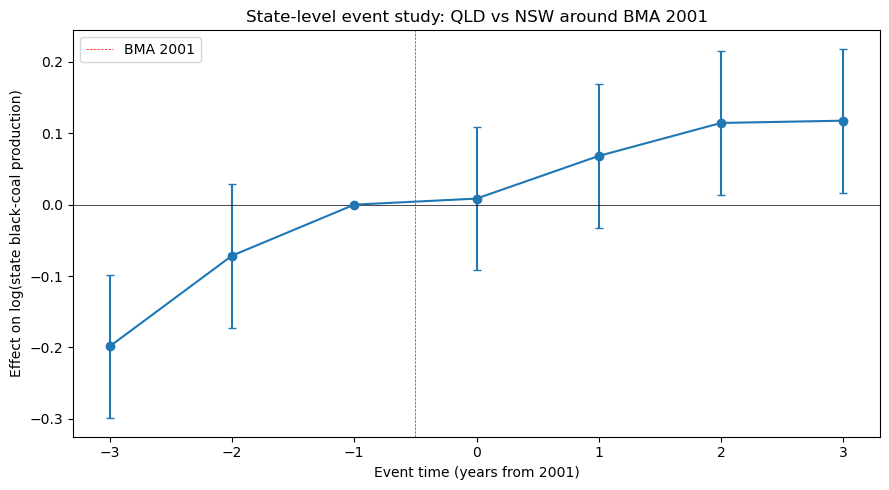

In [9]:
coefs, ses, evs = [], [], []
for n in EVENT_LEADS:
    if n == 1:
        coefs.append(0.0); ses.append(0.0); evs.append(-1); continue
    name = f'dlead{n}'
    if name in m_state.params.index:
        coefs.append(m_state.params[name]); ses.append(m_state.bse[name]); evs.append(-n)
for n in EVENT_LAGS:
    name = f'dlag{n}'
    if name in m_state.params.index:
        coefs.append(m_state.params[name]); ses.append(m_state.bse[name]); evs.append(n)
order = np.argsort(evs)
evs = np.array(evs)[order]; coefs = np.array(coefs)[order]; ses = np.array(ses)[order]

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(evs, coefs, yerr=1.96*ses, fmt='o-', capsize=3)
ax.axhline(0, color='black', lw=0.5)
ax.axvline(-0.5, color='red', lw=0.5, ls='--', label='BMA 2001')
ax.set_xlabel('Event time (years from 2001)')
ax.set_ylabel('Effect on log(state black-coal production)')
ax.set_title('State-level event study: QLD vs NSW around BMA 2001')
ax.legend(); plt.tight_layout(); plt.show()

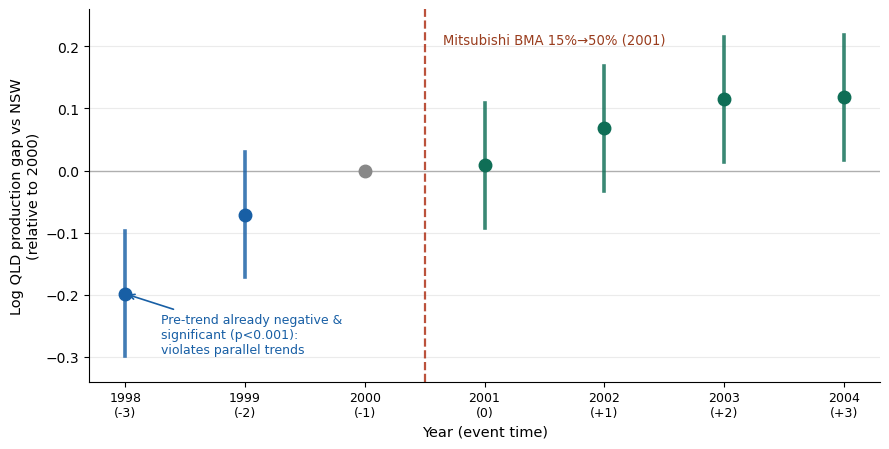

event_time  year   coef     95% CI            p
 -3        1998   -0.198   [-0.299, -0.098]   0.000
 -2        1999   -0.071   [-0.172, +0.029]   0.164
 -1        2000   +0.000   [+0.000, +0.000]   
 +0        2001   +0.008   [-0.092, +0.109]   0.869
 +1        2002   +0.068   [-0.032, +0.169]   0.184
 +2        2003   +0.114   [+0.014, +0.215]   0.026
 +3        2004   +0.118   [+0.017, +0.218]   0.022


In [10]:
rows = []
for n in EVENT_LEADS:                       # leads: 1998 (-3), 1999 (-2), 2000 (-1, ref)
    et, yr = -n, 2001 - n
    if n == 1:                              # omitted reference
        rows.append((et, yr, 0.0, 0.0, 0.0, np.nan))
    else:
        name = f'dlead{n}'
        c, se = m_state.params[name], m_state.bse[name]
        rows.append((et, yr, c, c - 1.96*se, c + 1.96*se, m_state.pvalues[name]))
for n in EVENT_LAGS:                         # lags: 2001 (0) ... 2004 (+3)
    name = f'dlag{n}'
    c, se = m_state.params[name], m_state.bse[name]
    rows.append((n, 2001 + n, c, c - 1.96*se, c + 1.96*se, m_state.pvalues[name]))

rows.sort(key=lambda r: r[0])
evs   = [r[0] for r in rows]
yrs   = [r[1] for r in rows]
coefs = [r[2] for r in rows]
los   = [r[3] for r in rows]
his   = [r[4] for r in rows]

PRE, POST, REF = '#185FA5', '#0F6E56', '#888888'

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.axhline(0, color='#888888', lw=1, alpha=0.6)
ax.axvline(-0.5, color='#B0341A', lw=1.6, ls='--', alpha=0.85)
ax.annotate('Mitsubishi BMA 15%→50% (2001)', xy=(-0.5, 0.20), xytext=(-0.35, 0.205),
            fontsize=9.5, color='#993C1D', ha='left')

for et, c, lo, hi in zip(evs, coefs, los, his):
    col = PRE if et < 0 else POST
    if et == -1:
        col = REF
    ax.plot([et, et], [lo, hi], color=col, lw=2.6, alpha=0.82, zorder=2)
    ax.plot(et, c, 'o', color=col, ms=9, zorder=3)

ax.annotate('Pre-trend already negative &\nsignificant (p<0.001):\nviolates parallel trends',
            xy=(-3, coefs[0]), xytext=(-2.7, coefs[0] - 0.10),
            fontsize=9, color=PRE, ha='left', va='bottom',
            arrowprops=dict(arrowstyle='->', color=PRE, lw=1.2))

ax.set_xticks(evs)
ax.set_xticklabels([f'{yr}\n({et:+d})' if et != 0 else f'{yr}\n(0)'
                    for et, yr in zip(evs, yrs)], fontsize=9)
ax.set_ylabel('Log QLD production gap vs NSW\n(relative to 2000)', fontsize=10.5)
ax.set_xlabel('Year (event time)', fontsize=10.5)
ax.set_ylim(-0.34, 0.26)
ax.grid(axis='y', alpha=0.25); ax.set_axisbelow(True)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

# Print the underlying numbers for the paper / appendix table
print('event_time  year   coef     95% CI            p')
for et, yr, c, lo, hi in zip(evs, yrs, coefs, los, his):
    p = '' if et == -1 else f'{[r[5] for r in rows if r[0]==et][0]:.3f}'
    print(f'{et:+3d}        {yr}   {c:+.3f}   [{lo:+.3f}, {hi:+.3f}]   {p}')

### Falsification — WA iron ore should NOT show a 2001 effect

Japanese equity expansion in WA iron ore happened in 1977 (Robe River 35→47%), not 2001. So a placebo-style test on WA vs SA iron ore around 2001 should be null.

In [11]:
fa = mudd[(mudd.commodity == 'iron_ore')
          & (mudd.state.isin(['WA', 'SA']))
          & (mudd.year.between(1980, 2010))].copy()
fa['log_prod'] = np.log(fa.production_tonnes.clip(lower=1))
fa['treated_wa'] = (fa.state == 'WA').astype(int)
if len(fa) > 10 and fa.state.nunique() == 2:
    for n in EVENT_LEADS:
        if n == 1: continue
        fa[f'dlead{n}'] = ((fa.year == 2001 - n) & (fa.treated_wa == 1)).astype(int)
    for n in EVENT_LAGS:
        fa[f'dlag{n}'] = ((fa.year == 2001 + n) & (fa.treated_wa == 1)).astype(int)
    fa_w = fa[fa.year.between(1996, 2006)].copy()
    try:
        m_f = smf.ols(f'log_prod ~ {rhs} + C(state) + C(year)', data=fa_w).fit(cov_type='HC1')
        print('Falsification (WA iron ore vs SA iron ore around 2001):')
        print(m_f.summary().tables[1])
    except Exception as e:
        print('Falsification fit failed:', e)
else:
    print(f'Insufficient SA/WA iron ore data ({len(fa)} rows); skipping.')

Falsification (WA iron ore vs SA iron ore around 2001):
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          14.6995      0.071    206.404      0.000      14.560      14.839
C(state)[T.WA]      4.1509      0.064     64.399      0.000       4.025       4.277
C(year)[T.1997]     0.0312      0.083      0.376      0.707      -0.131       0.194
C(year)[T.1998]     0.1914      0.071      2.687      0.007       0.052       0.331
C(year)[T.1999]     0.2164      0.071      3.039      0.002       0.077       0.356
C(year)[T.2000]     0.1011      0.082      1.234      0.217      -0.059       0.262
C(year)[T.2001]     0.2179      0.071      3.060      0.002       0.078       0.357
C(year)[T.2002]     0.3070      0.071      4.310      0.000       0.167       0.447
C(year)[T.2003]     0.1052      0.071      1.478      0.140      -0.034       0.245
C(year)[T.2004]     

/opt/anaconda3/envs/cs224n/lib/python3.10/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 6
  warnings.warn('covariance of constraints does not have full '


### Robe River 1977 — WA iron ore single-state break test

Nippon Steel + Sumitomo Metal joined Robe River in 1977, raising Japanese equity 35→47%. There is no clean control state (NSW/SA iron-ore production is minimal), so the cleanest test is a simple pre/post-1977 break in WA iron-ore growth.

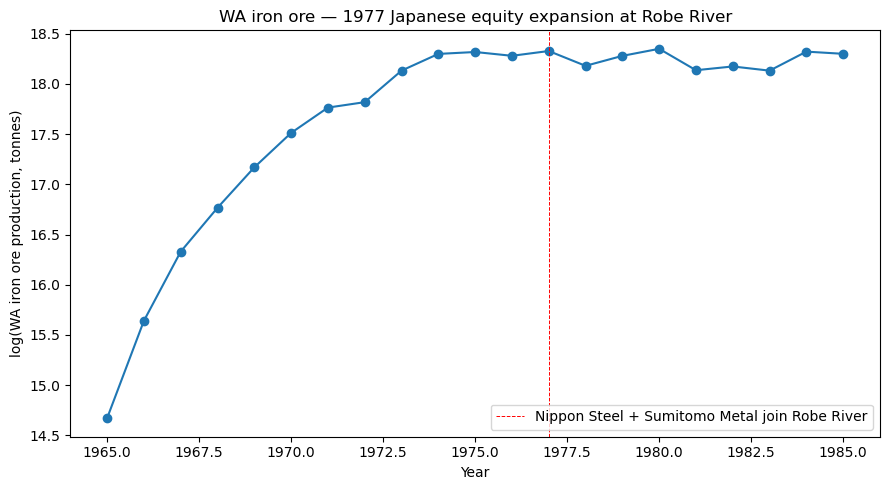

In [12]:
wa_fe = mudd[(mudd.commodity == 'iron_ore') & (mudd.state == 'WA')
             & mudd.year.between(1965, 1985)].copy()
wa_fe['log_prod'] = np.log(wa_fe.production_tonnes)
wa_fe['post_1977'] = (wa_fe.year >= 1977).astype(int)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(wa_fe.year, wa_fe.log_prod, 'o-')
ax.axvline(1977, color='red', lw=0.7, ls='--', label='Nippon Steel + Sumitomo Metal join Robe River')
ax.set_xlabel('Year'); ax.set_ylabel('log(WA iron ore production, tonnes)')
ax.set_title('WA iron ore — 1977 Japanese equity expansion at Robe River')
ax.legend(); plt.tight_layout(); plt.show()

## Specification B — Cross-sectional regression on seed-data project panel

Where `japan_share_of_output_pct` is observed in `data/manual/project_production_annual.csv`, regress on Japanese equity. Small-N descriptive only until hand-coding fills more cells.

In [13]:
cs = project_panel.dropna(subset=['japan_share_of_output_pct']).copy()
if len(cs) < 5:
    print(f'Only {len(cs)} observations with non-null japan_share_of_output_pct.')
    print('Cross-section regression needs more hand-coded japan-share data.')
    print('Currently observable rows:')
    if len(cs) > 0:
        print(cs[['project', 'year', 'japanese_equity_pct', 'japan_share_of_output_pct']].to_string(index=False))
else:
    m_cs = smf.ols('japan_share_of_output_pct ~ japanese_equity_pct + C(commodity)', data=cs).fit()
    print(m_cs.summary())

Only 0 observations with non-null japan_share_of_output_pct.
Cross-section regression needs more hand-coded japan-share data.
Currently observable rows:


## Specification C — Aspirational project-level BMA 2001 event study

Scaffold for the project-level event study that requires hand-coded annual production for the BMA mines (Goonyella, Peak Downs, Saraji) and Bowen Basin control mines (German Creek, Oaky Creek, Curragh, Moranbah North), 1996–2006. Reports a coverage diagnostic until that data is in place.

In [14]:
coverage = (project_panel.groupby('project')
                         .agg(production_obs=('mtpa_production', lambda s: s.notna().sum()),
                              year_min=('year', 'min'), year_max=('year', 'max')))
print(coverage)
print(f'\nNon-null mtpa_production cells: {project_panel.mtpa_production.notna().sum()}')

BMA_MINES = ['Goonyella (CQCA/BMA)', 'Peak Downs (CQCA/BMA)', 'Saraji (CQCA/BMA)']
CONTROL_MINES_EXPECTED = ['German Creek', 'Oaky Creek', 'Curragh', 'Moranbah North']
have_controls = sum(1 for mname in CONTROL_MINES_EXPECTED if mname in project_panel.project.unique())
print(f'\nControl mines present in panel: {have_controls}/{len(CONTROL_MINES_EXPECTED)}')
print('To enable project-level BMA event study:')
print('  1. Add control rows to data/manual/coal_iron_ore_projects_aus_jpn.csv (equity=0)')
print('  2. Hand-code annual Mtpa to data/manual/project_production_annual.csv')
print('  3. Re-run scripts/build_project_panel.py')

                       production_obs  year_min  year_max
project                                                  
Bengalla                            1      1999      2010
Goonyella (CQCA/BMA)                1      1971      2010
Hail Creek                          1      2003      2010
Mount Newman                        1      1969      2010
Peak Downs (CQCA/BMA)               1      1972      2010
Robe River                          1      1972      2010
Saraji (CQCA/BMA)                   1      1974      2010
Ulan                                1      1986      2010

Non-null mtpa_production cells: 8

Control mines present in panel: 0/4
To enable project-level BMA event study:
  1. Add control rows to data/manual/coal_iron_ore_projects_aus_jpn.csv (equity=0)
  2. Hand-code annual Mtpa to data/manual/project_production_annual.csv
  3. Re-run scripts/build_project_panel.py


In [15]:
es = project_panel[(project_panel.commodity == 'coking_coal')
                   & project_panel.year.between(1996, 2006)].copy()
es['treated'] = es['project'].isin(BMA_MINES).astype(int)
es['log_mtpa'] = np.log(es['mtpa_production'].clip(lower=0.1))
n_treated = es[es.treated==1]['project'].nunique()
n_control = es[es.treated==0]['project'].nunique()
if n_control > 0 and es.log_mtpa.notna().sum() > 20:
    for n in EVENT_LEADS:
        if n == 1: continue
        es[f'dlead{n}'] = ((es.year == 2001 - n) & (es.treated == 1)).astype(int)
    for n in EVENT_LAGS:
        es[f'dlag{n}'] = ((es.year == 2001 + n) & (es.treated == 1)).astype(int)
    es_fit = es.dropna(subset=['log_mtpa'])
    m = smf.ols(f'log_mtpa ~ {rhs} + C(project) + C(year)', data=es_fit).fit(
        cov_type='cluster', cov_kwds={'groups': es_fit['project']})
    print(m.summary().tables[1])
else:
    print(f'Specification C not yet runnable: {n_treated} treated, {n_control} control mines, '
          f'{es.log_mtpa.notna().sum()} non-null log_mtpa rows.')

Specification C not yet runnable: 3 treated, 1 control mines, 1 non-null log_mtpa rows.


## Threats to validity (write these into the paper)

### Specification A (state-level)
- **Aggregation bias** — pooling all QLD mines treats non-BMA mines (Hail Creek, Curragh, Newlands) as if they were affected by BMA-Mitsubishi 2001. The state-level estimate is an *attenuated* version of the true BMA effect.
- **NSW isn't a perfect control** — Hunter Valley thermal coal had its own expansion drivers.
- **Year FE absorbs common shocks** (coking-coal price boom 2003–2004) but not state-specific deviations.

### Specification C (project-level)
- **Treatment endogeneity** — Mitsubishi acquired QCT precisely *because* of expected Japan exports.
- **No anticipation** — QCT acquisition announced Nov 2000; treat 2001 as treatment year, run sensitivity using 2000.
- **Outcome proxy** — log(Mtpa production) is a capacity proxy, not direct Japan-share.

### Universal
- Mudd state-level data is RAW coal tonnes (not saleable, not Japan-bound). The link to Japan exports is indirect.
- The aggregate Japan-coal-exports series in `fossil_era_panel.csv` cannot be disaggregated by state without port-of-loading data.